<a href="https://colab.research.google.com/github/miguelmoralesosorio/s7-connectatel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?

---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico**
- `date` (0.125%): Se recomienda eliminar las filas con valores nulos, ya que representan una proporción mínima y no afectan significativamente el tamaño del dataset.
- `city` (11.73%): Se recomienda imputar los valores nulos con la moda, ya que representan una proporción intermedia y la ciudad más frecuente permite conservar estos registros para el análisis.
- `duration` (55.19%) y `length` (44.74%): Se recomienda mantener los valores nulos, ya que no representan errores: `duration` no aplica a mensajes y `length` no aplica a llamadas.
- `churn_date` (88.35%): Se recomienda mantener los valores nulos, ya que indican que la mayoría de los clientes continúan activos y solo se registra una fecha cuando el cliente cancela el servicio.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
columnas_users = ['user_id', 'age']
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
users['user_id'].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3995    False
3996    False
3997    False
3998    False
3999    False
Name: user_id, Length: 4000, dtype: bool

In [ ]:
users['age'].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3995     True
3996     True
3997     True
3998     True
3999     True
Name: age, Length: 4000, dtype: bool

- La columna `user_id` no cuenta con valores duplicados porque cada id debe de identificar a un cliente único.
- La columna `age` tiene un rango de 18 a 79 años, lo cual es coherente con una base de clientes adulta, sin valores atípicos como edades negativas o irreales.

In [ ]:
# explorar columnas numéricas de usage
columnas_usage = ['id', 'user_id', 'duration', 'length']
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [ ]:
usage['id'].duplicated().value_counts()

False    40000
Name: id, dtype: int64

In [ ]:
usage['user_id'].duplicated().value_counts()

True     36001
False     3999
Name: user_id, dtype: int64

- La columna `id` no presenta duplicados, con 40,000 valores únicos, por lo que funciona correctamente como identificador de cada registro. Por otro lado, `user_id` presenta 3,999 valores únicos y 36,001 duplicados, lo cual es esperado porque un mismo usuario puede realizar múltiples llamadas o enviar varios mensajes.La columna id no presenta duplicados, con 40,000 valores únicos, por lo que funciona correctamente como identificador de cada registro. Por otro lado, user_id presenta 3,999 valores únicos y 36,001 duplicados, lo cual es esperado porque un mismo usuario puede realizar múltiples llamadas o enviar varios mensajes..
- Las columnas `duration` y `length` presentan nulos estructurales, es decir, valores faltantes que no representan errores de carga, sino que indican que la variable no aplica al tipo de actividad registrado. De las 40,000 filas, `duration` cuenta con 17,924 valores registrados y 22,076 valores nulos, mientras que `length` cuenta con 22,104 valores registrados y 17,896 valores nulos. Esto se debe a que cada columna aplica a un tipo de actividad diferente; por ejemplo, un mensaje no tiene una duración de llamada.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan', 'churn_date']
users[['city', 'plan', 'churn_date']].describe()

,city,plan,churn_date
count,3531,4000,466
unique,7,2,197
top,Bogotá,Basico,"1,71763E+18"
freq,808,2595,6


In [ ]:
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` cuenta con 7 valores únicos. Se identificó el valor `"?"` como un dato inesperado o sentinel, presente en 96 registros, por lo que debe tratarse como valor nulo antes de continuar con el análisis.
- La columna `plan` cuenta con 2 categorías válidas: `Basico` con 2,595 registros y `Premium` con 1,405 registros. No se detectaron valores inválidos o categorías inesperadas.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` cuenta con 2 categorías únicas: `text` con 22,092 registros y `call` con 17,908 registros. Ambas categorías suman las 40,000 filas del dataset `usage` y no se detectaron valores inesperados, vacíos o inválidos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?

**Reflexión final**
- `city`: Se identificó el sentinel `"?"` en 96 registros, por lo que se recomienda reemplazarlo por valores nulos (`NaN`) y posteriormente imputarlos con la moda para conservar los registros.
- `duration` y `length`: Presentan valores nulos estructurales, pero no son valores inválidos, ya que corresponden a actividades donde la variable no aplica. Se recomienda mantenerlos como nulos y tratarlos según el tipo de actividad.
- `plan` y `type`: No se detectaron valores inválidos, vacíos o categorías inesperadas, por lo que no requieren modificaciones.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year

0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
3995    2024
3996    2024
3997    2024
3998    2024
3999    2024
Name: reg_date, Length: 4000, dtype: int64

In [ ]:
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

In [ ]:
users['reg_date'].min()

Timestamp('2022-01-01 00:00:00')

In [ ]:
users['reg_date'].max()

Timestamp('2026-05-10 00:00:00')

En `reg_date`,  el motivo que exista un rango amplio es debido a que los usuarios hicieron sus registros a lo largo de esos años y también representa cuándo se registró el usuario (un evento que puede haber pasado en cualquier momento desde 2022).

In [ ]:
usage['date'].dt.year

0        2024.0
1        2024.0
2        2024.0
3        2024.0
4        2024.0
          ...  
39995    2024.0
39996    2024.0
39997    2024.0
39998    2024.0
39999    2024.0
Name: date, Length: 40000, dtype: float64

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

In [ ]:
usage['date'].min()

Timestamp('2024-01-01 00:00:00')

In [ ]:
usage['date'].max()

Timestamp('2024-06-30 00:00:00')

En `date`, se encontró únicamente el año 2024. Además, hay 50 valores nulos, ya que de las 40000 filas totales, solo 39950 tienen un valor no nulo en esta columna. En este caso, debido a que estamos hablando de los registros recientes, tenemos que tomar el año 2024 como principal dato debido a que es el ultimo año contemplado.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico final**
- En la columna `reg_date` hay un rango amplio de registros desde 2022 debido a que esa columna toma como punto de partida la fecha donde los usuarios se registraron por primera vez.

- En `date` se toma el 2024 como punto de partida debido a que estamos hablando de registros recientes.

- Para comprobarlo, se diagnosticaron los máximos (`.max()`) y mínimos (`.min()`) de ambas columnas y los diagnósticos fueron:

- `reg_date`:
  - `.min()`: `2022-01-01`
  - `.max()`: `2024-12-31`

- `date`:
  - `.min()`: `2024-01-01`
  - `.max()`: `2024-06-30

- Esto nos indica que los valores erroneos e imposibles son inexistentes

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
city = users['city'].mode(0)
users['city'] = users['city'].fillna(city[0])
users['city'].value_counts(dropna=False)

Bogotá      1373
CDMX         730
Medellín     616
GDL          450
Cali         424
MTY          407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
fechas_invalidas = users['reg_date'].dt.year > 2024
users.loc[fechas_invalidas, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`:

No hay necesidad de ejecutar o modificar los nulos en las columnas `duration` y `length` debido a que los mensajes no tienen duración y las llamadas no tienen longitud, por lo cual esos tipos de nulos tienen una explicación clara dependiendo de la columna `type`. Por lo cual, son catalogados como MAR.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on='user_id')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,Bogotá,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

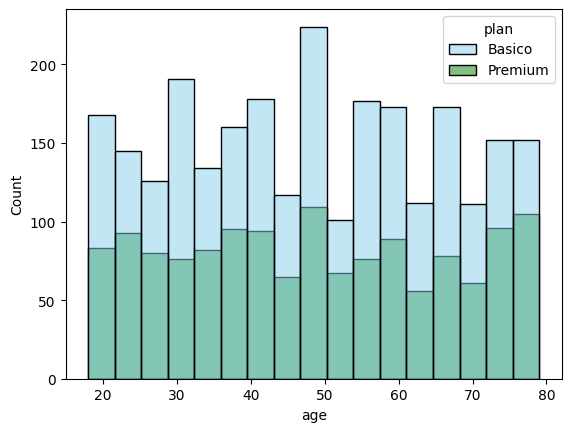

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights:
- Distribución: Las edades están concentradas en las personas de entre 20 a 50 años de edad a lo largo del rango, en donde la diferencia favorece al Plan Premium en dicho rango de edad.

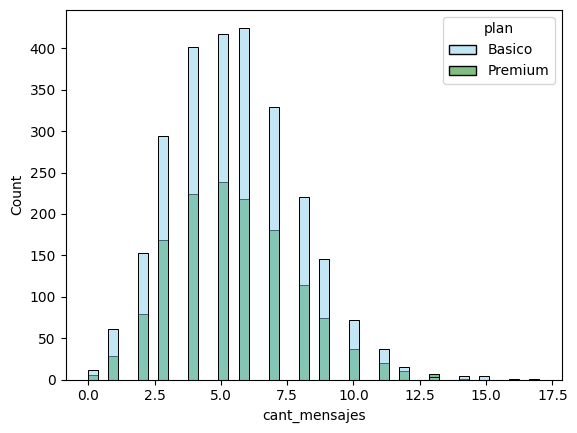

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights:
- La distribución se concentra en su mayoría en los valores bajos, específicamente en los rangos de 2 a 8 mensajes favoreciendo al Plan Premium de nueva cuenta en dicho rango.

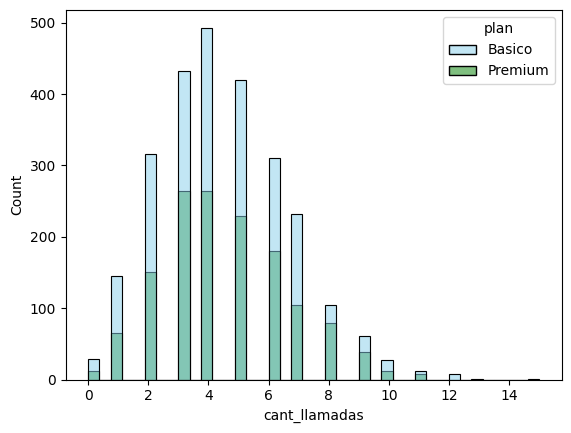

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights:
- Distribución: La distribución se concentra en su mayoría en los valores bajos, específicamente en los rangos de 2 a 8 llamadas favoreciendo nuevamente al Plan Premium en dicho rango.

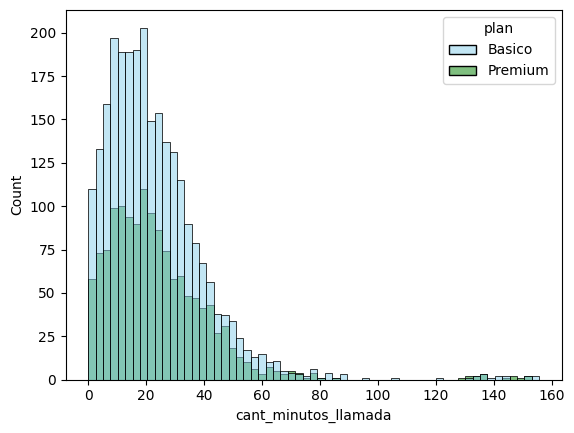

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights:
- La distribución se concentra en su mayoría en los valores bajos, específicamente en los rangos de 10 a 60 minutos por llamada favoreciendo al Plan Básico en dicho rango.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

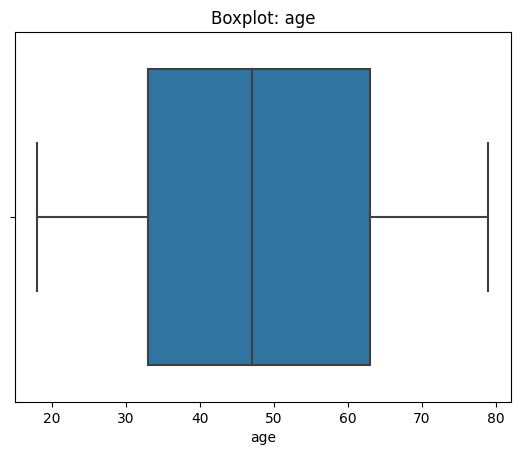

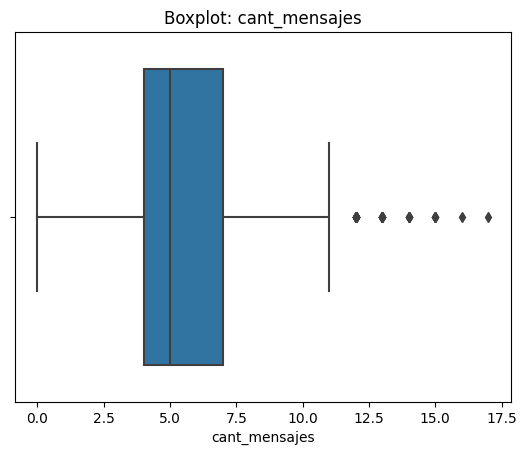

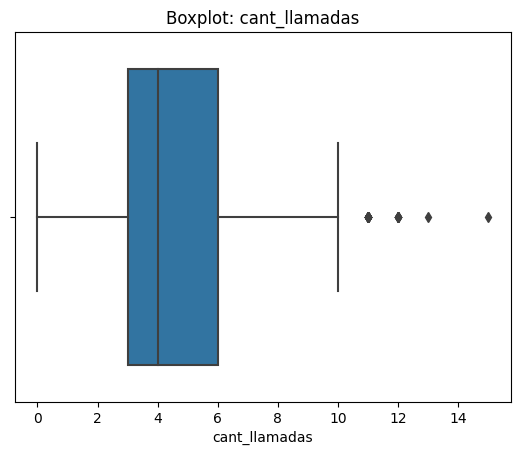

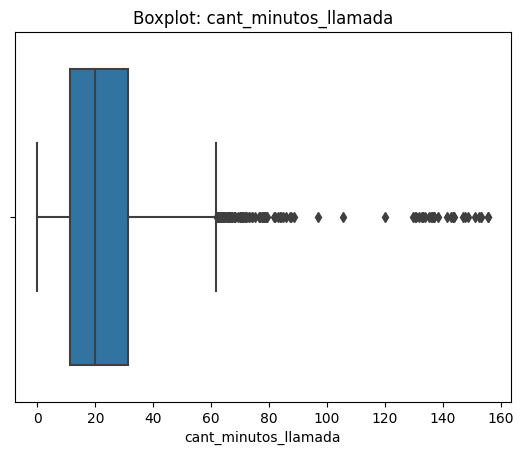

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- `age`: no presenta outliers que alteren tanto la columna como el Boxplot
- `cant_mensajes`: el bigote derecho llega hasta 11 con 6 outliers identificados desde 11 hasta 16.5
- `cant_llamadas`: cuenta con 4 outliers por encima del bigote derecho que tiene un límite de 10
- `cant_minutos_llamada`: presenta el comportamiento más atípico, ya que contiene una gran cantidad de outliers por encima del bigote derecho, cuyo límite se encuentra aproximadamente entre 60 y 65 minutos. Estos valores atípicos se extienden hasta cerca de 160 minutos, aunque no es posible determinar con exactitud su cantidad.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q3 = user_profile[col].quantile(0.75)
    Q1 = user_profile[col].quantile(0.25)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(col, limite_superior)

cant_mensajes 11.5
cant_llamadas 10.5
cant_minutos_llamada 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- `cant_mensajes`: Al comparar el límite superior (11.5) con el máximo (17), se observa una diferencia relativamente pequeña, con solo 6 valores fuera del rango. Esto sugiere a mantener los outliers porque pueden existir usuarios que mandan mensajes de forma mas recurrente que el resto.
  
- `cant_llamadas`: Al comparar el límite superior (10.5) con el máximo (15), se observa una diferencia relativamente pequeña, con solo 4 valores fuera del rango. Esto sugiere que existen usuarios que realizan llamadas más frecuentes que el resto, por lo que se decide mantener los outliers.

- `cant_minutos_llamada`: Al comparar el límite superior (61.86) con el máximo (155.69), se observa una diferencia considerable, con una enorme variedad de valores fuera del rango. Sin embargo, como esta columna representa la suma de minutos de llamada de cada usuario, es esperable que quienes hacen llamadas con más frecuencia (sobre todo cortas) acumulen sumas mucho más altas, por lo que se decide mantener los outliers.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,Bogotá,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(fila):
    if fila['age'] < 30:
        return 'Joven'
    elif fila['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,Bogotá,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

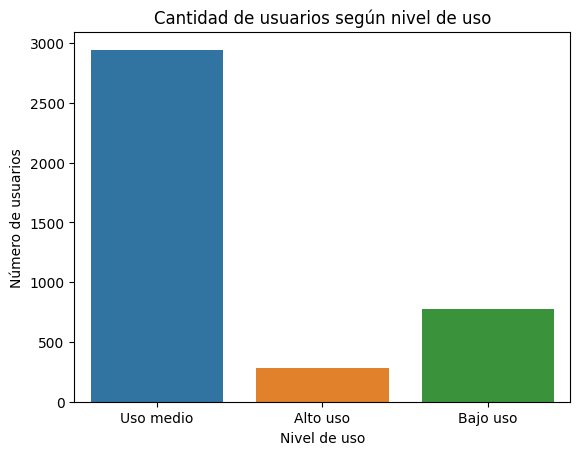

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Cantidad de usuarios según nivel de uso')
plt.xlabel('Nivel de uso')
plt.ylabel('Número de usuarios')
plt.show()

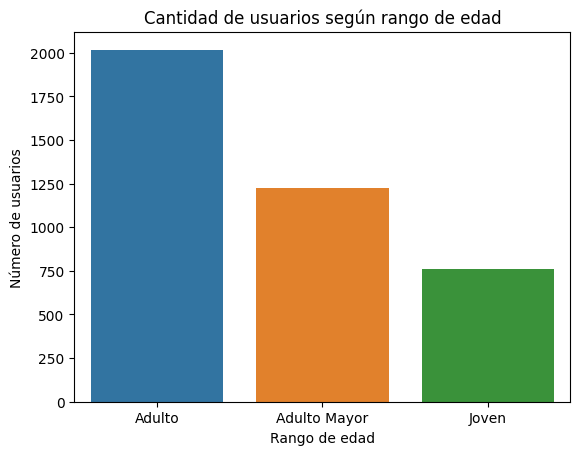

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Cantidad de usuarios según rango de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Número de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
-
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


Durante la limpieza de los datos se identificaron varios problemas que debían tratarse de forma distinta según su origen. En primer lugar, se detectaron 469 nulos en la columna `city` (11.73% del total) del dataset `users`, lo cual dificulta analizar qué ciudades tienen más clientes y decidir dónde poner nuevas antenas o tiendas físicas. Además, 40 registros (1%) presentaban fechas de alta nulas en el mismo dataset, un porcentaje bajo que probablemente corresponde a errores puntuales de digitación o de formato. Asimismo, se detectaron 22076 nulos en la columna `duration` (55.19% del total de las filas) y 17896 nulos en la columna `length` (44.74% del total de las filas), los cuales no son aleatorios: `duration` aparece nulo cuando la actividad es un mensaje de texto, mientras que `length` aparece nulo cuando la actividad es una llamada. Por lo tanto, al calcular la duración promedio de las llamadas de un cliente, se deben excluir los nulos en vez de imputarlos con la media, ya que no representan la duración de una llamada o la longitud de un mensaje. Finalmente, la columna `churn_date` cuenta con 3534 nulos (88.35% del total de las filas). Sin embargo, estos nulos no representan un error, sino que indican qué clientes siguen activos, ya que solo se registra una fecha cuando el cliente cancela su servicio.

En la categoría `grupo_uso` se crearon las siguientes subcategorías. Primero, tenemos la subcategoría `Bajo uso` para la cantidad de mensajes y llamadas menores a 5. Después, tenemos la subcategoría `Uso medio` para la cantidad de mensajes y llamadas menores a 10. Luego, tenemos la subcategoría `Alto uso` para el resto de los casos. Al revisar el countplot, se observa que el grupo de usuarios que realizan un `Uso medio` de llamadas y mensajes es el mayor, mientras que el grupo de usuarios que realizan un `Alto uso` es el menor, por lo cual la implicación de negocio es que la mayoría de los clientes necesitaría un plan básico/medio.

Por otra parte, en la categoría `grupo_edad` se crearon las siguientes categorías. Primero, tenemos la categoría `Joven` para las personas menores a 30 años. Despues, tenemos la categoría `Adulto` para las personas entre 30 y 60 años. Luego, tenemos la categoría `Adulto Mayor` para el resto de los casos. Al revisar el countplot, se observa que el grupo `Adulto` es el más numeroso, por lo cual la sugerencia es que ConnectaTel apunte su marketing a los adultos de entre 30 y 60 años.

Acorde al dato de retención global, la base de clientes es estable y leal. Sin embargo, el grupo `Alto uso` está relacionado con el mayor consumo de servicio (más mensajes/llamadas/minutos), lo que sugiere que hay clientes que dependen más de él y probablemente generan más ingresos, aunque sean minoría en cantidad de clientes.

Los outliers se identificaron principalmente en `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`. En las dos primeras variables, los pocos valores extremos corresponden a usuarios con un uso intensivo de mensajería y llamadas, consistente con el grupo de `Alto uso`. En `cant_minutos_llamada` se observa una cantidad mucho mayor de outliers debido a usuarios que realizan llamadas individuales muy largas, elevando considerablemente su promedio de minutos.

Aunque este grupo de usuarios es reducido, representa una oportunidad de mayores ingresos, pero también un mayor consumo de recursos. Por ello, es importante analizar su rentabilidad y comportamiento para ofrecer planes adecuados que permitan mantenerlos como clientes.

Para el segmento `Alto uso`, se recomienda relanzar un Plan Premium con llamadas y mensajes ilimitados, adaptado a clientes con consumo intensivo y que podría ayudar a reducir el riesgo de cancelación.

El grupo de 30 a 60 años concentra la mayor cantidad de clientes, por lo que se pueden ofrecer beneficios por renovación anual y antigüedad. Para atraer al segmento joven, la recomendación sería un plan de entrada económico pensado para ese nivel de consumo.

Finalmente, para los usuarios con un consumo excepcionalmente alto de minutos de llamada, identificados como outliers en `cant_minutos_llamada`, se recomienda crear un plan especial con un límite de minutos mayor, con el objetivo de adaptar el servicio a su consumo y mejorar su rentabilidad.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron 469 nulos en la columna `city` (11.73% del total) del dataset `users`, lo cual dificulta analizar qué ciudades tienen más clientes, decidir dónde poner nuevas antenas o tiendas físicas. Además, 40 registros (1%) presentaban fechas de alta nulas en el mismo dataset, un porcentaje bajo que probablemente corresponde a errores puntuales de digitación o de formato.
- Se detectaron 22076 nulos en la columna `duration` (55.19% del total de las filas) y 17896 nulos en la columna `length` (44.74 del total de las filas), los cuales no son aleatorios: `duration` aparece nulo cuando la actividad es un mensaje de texto, y `length` aparece nulo cuando la actividad es una llamada. Por lo tanto, al calcular la duración promedio de las llamadas de un cliente, se deben excluir los nulos en vez de imputarlos con la media, ya que no representan la duración de una llamada o longitud de un mensaje.
- La columna `churn_date` cuenta con 3534 nulos (88.35% del total de las filas). Sin embargo, estos nulos no representan un error, sino que indican qué clientes siguen activos, ya que solo se registra una fecha cuando el cliente cancela su servicio.


🔍 **Segmentos por Edad**
- `Joven`: Personas menores a 30 años. El segmento menos númeroso acorde al countplot
- `Adulto Mayor`: Personas mayores a 60 años. El segmento que es considerado como el punto medio entre los `Jovenes` y `Adultos`
- `Àdulto`: Personas con un rango de edad entre 30 y 60 años. El más numeroso de los 3 segmentos


📊 **Segmentos por Nivel de Uso**
- `Bajo uso`: Cantidad de mensajes y llamadas menores a 5.
- `Uso medio`: Cantidad de mensajes y llamadas menores a 10.
- `Alto uso`: Cantidad de mensajes y llamadas mayores a 10


➡️ Esto sugiere que la mayoría de usuarios hace un uso medio/bajo de los mensajes y llamadas, lo que implica que la compañía debe enfocarse en un plan básico medio; sin embargo, una minoría de usuarios con un uso alto de mensajes y llamadas genera más ingresos, lo cual coincide con los valores atípicos detectados en la cantidad de minutos por llamada


💡 **Recomendaciones**
- `Segmento joven`: presenta un uso bajo/medio de llamadas y mensajes, por lo que requiere un plan de entrada económico.
- `Uso bajo/medio`: la mayoría de los clientes puede cubrir sus necesidades con planes básicos o medios.
- `Uso alto`: la minoría de los clientes requiere un plan Premium con llamadas y mensajes ilimitados.
- `Oportunidad de negocio`: adaptar los planes al nivel de consumo puede mejorar la satisfacción y retención de clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`